In [1]:
import stellarvista as sv

/home/sampasmann/miniconda3/envs/stellarvista/lib/python3.12/site-packages/openmc/config.py:65: UserWarning: '/home/sampasmann/Documents/endfb-viii.0-hdf5/cross_sections.xml' does not exist.
  warnings.warn(f"'{value}' does not exist.")
/home/sampasmann/miniconda3/envs/stellarvista/lib/python3.12/site-packages/pymoab/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Loading the `weight_windows.h5`, we see the first level of the `MultiBlock` lists the individual weight window sets contained within the .h5 file.
In this case, we only have one set of weight windows `neutron_ww_1`. However, it may be possible that other weight window sets are contained in the file,
as would be the case if weight windows were used for photon transport as well.

In [2]:
pv_mesh = sv.load_wws_to_pv('./model_labrynth/weight_windows.h5')
display(pv_mesh)

MultiBlock (0x7f36a81da2c0)
  N Blocks:   1
  X Bounds:   -2.681e+03, 2.721e+03
  Y Bounds:   -1.000e+00, 1.501e+03
  Z Bounds:   -3.014e+03, 3.138e+03

The second layer of the Block shows two structured grids, one for each energy bin.

In [3]:
display(pv_mesh[0]) # Note, pv_mesh[0] is equivalent to pv_mesh['neutron_ww_1']

MultiBlock (0x7f36a81d9e40)
  N Blocks:   2
  X Bounds:   -2.681e+03, 2.721e+03
  Y Bounds:   -1.000e+00, 1.501e+03
  Z Bounds:   -3.014e+03, 3.138e+03

Finally, the last layer shows us the data for the lower and upper weight window bounds for this energy bin.
Which can be plotted like so:

StructuredGrid (0x7f36a81da0e0)
  N Cells:      1000000
  N Points:     1030301
  X Bounds:     -2.681e+03, 2.721e+03
  Y Bounds:     -1.000e+00, 1.501e+03
  Z Bounds:     -3.014e+03, 3.138e+03
  Dimensions:   101, 101, 101
  N Arrays:     3

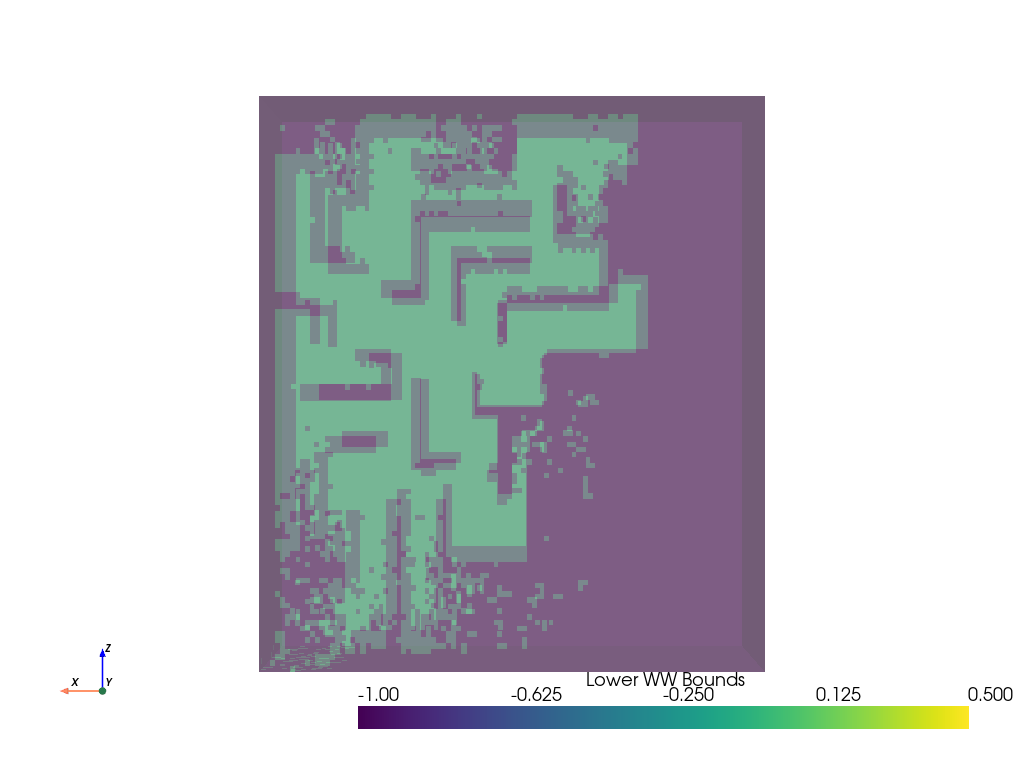

In [4]:
display(pv_mesh[0][0])
pv_mesh[0][0].plot(opacity=0.4, jupyter_backend='static', cpos=[0,1,0])

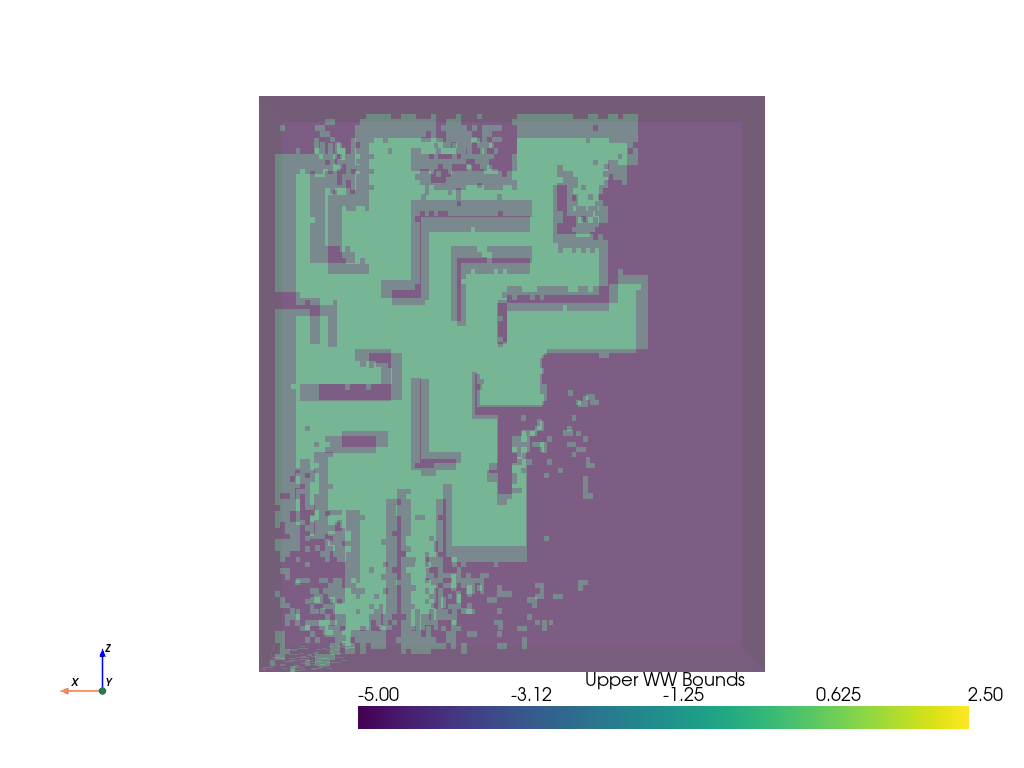

In [5]:
pv_mesh[0][0].set_active_scalars('Upper WW Bounds')
pv_mesh[0][0].plot(opacity=0.4, jupyter_backend='static', cpos=[0,1,0])